In [3]:
import pandas as pd
import math
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

In [8]:
def load_data():
    df_stock = pd.read_csv('./Data/Fama_French/stock_daily_data.csv')
    df_stock['date'] = pd.to_datetime(df_stock['date'])
    df_1a_mean = pd.read_csv('./Data/Fama_French/risk_scores_item_1a_mean.csv')
    df_7_mean = pd.read_csv('./Data/Fama_French/risk_scores_item_7_mean.csv')
    df_score = pd.merge(df_1a_mean, df_7_mean,
                    on=['year', 'ticker'],
                    suffixes=('_1a', '_7'),
                    how='inner')
    df_score.dropna()
    df_score['1a_minus_7'] = df_score['risk_score_1a'] - df_score['risk_score_7']
    return df_stock, df_score

df_stock, df_score = load_data()
df_score

,year,ticker,risk_score_1a,risk_score_7,1a_minus_7
0,2020,AAPL,3.411765,4.000000,-0.588235
1,2021,AAPL,4.473684,3.625000,0.848684
2,2020,ABBV,3.125000,3.000000,0.125000
3,2021,ABBV,3.125000,2.333333,0.791667
4,2022,ABBV,3.300000,2.750000,0.550000
...,...,...,...,...,...
1044,2023,ZBRA,3.222222,1.000000,2.222222
1045,2020,ZTS,6.461538,5.500000,0.961538
1046,2021,ZTS,5.727273,5.000000,0.727273
1047,2022,ZTS,3.150000,5.200000,-2.050000


In [38]:
def construct_portfolio_v2(df_stock, df_score, split_num=20, bool_print=True):
    rebalance_years = sorted(df_score['year'].unique())
    all_portfolio_returns = []
    for year in rebalance_years:
        df_year = df_score[df_score['year'] == year].copy()
        df_year = df_year.sort_values(by='1a_minus_7', ascending=False)

        portfolio_high_risk = df_year[:split_num]['ticker'].tolist()
        portfolio_low_risk = df_year[-split_num:]['ticker'].tolist()

        if bool_print:
            print("Year:", year)
            print("Shape of df_year:", df_year.shape)
            print("High Risk Tickers:", portfolio_high_risk)
            print("Low Risk Tickers:", portfolio_low_risk)

        holding_period_start = pd.to_datetime(f'{year+1}-07-01')
        holding_period_end = pd.to_datetime(f'{year+2}-06-30')

        period_data = df_stock[
            (df_stock['date'] >= holding_period_start) & 
            (df_stock['date'] <= holding_period_end)
        ]

        high_risk_score = period_data[period_data['ticker'].isin(portfolio_high_risk)].groupby('date')['return'].mean().to_list()
        low_risk_score = period_data[period_data['ticker'].isin(portfolio_low_risk)].groupby('date')['return'].mean().to_list()
    
        period_results = pd.DataFrame({
            'date': period_data['date'].unique(),
            'High': high_risk_score,
            'Low': low_risk_score,
            'S&P 500': period_data.groupby('date')['return'].mean().to_list()
        })
        period_results.set_index('date', inplace=True)
        all_portfolio_returns.append(period_results)
    df_portfolio_returns = pd.concat(all_portfolio_returns)
    return df_portfolio_returns

construct_portfolio_v2(*load_data(), split_num=20)  # Adjust split_num as needed



Year: 2020
Shape of df_year: (362, 5)
High Risk Tickers: ['CCI', 'BLDR', 'WBD', 'MRNA', 'CTVA', 'CMG', 'ADP', 'AKAM', 'PM', 'AMP', 'NOC', 'AMD', 'CPRT', 'TXN', 'MCO', 'KMI', 'PLD', 'FAST', 'CRWD', 'DOW']
Low Risk Tickers: ['ALGN', 'DD', 'AME', 'MTB', 'LIN', 'FSLR', 'KO', 'VICI', 'ADBE', 'ISRG', 'EMR', 'AMAT', 'ANET', 'MPC', 'HAS', 'HRL', 'BRO', 'CB', 'BALL', 'GOOG']
Year: 2021
Shape of df_year: (335, 5)
High Risk Tickers: ['CCI', 'CSGP', 'UBER', 'SBAC', 'STE', 'BFB', 'CPB', 'GLW', 'FDS', 'HPE', 'MPWR', 'ATO', 'DOW', 'GDDY', 'TDY', 'MO', 'CAT', 'SLB', 'JKHY', 'NUE']
Low Risk Tickers: ['CPAY', 'DIS', 'SNPS', 'TJX', 'CBOE', 'ADBE', 'HWM', 'CPT', 'AMZN', 'AMP', 'MRK', 'TXN', 'CPRT', 'FDX', 'YUM', 'AXP', 'BKNG', 'LYV', 'KKR', 'HD']
Year: 2022
Shape of df_year: (226, 5)
High Risk Tickers: ['SLB', 'EPAM', 'SNA', 'UDR', 'CHTR', 'CCI', 'CMG', 'LYB', 'WST', 'CHRW', 'MKTX', 'OTIS', 'EFX', 'FI', 'PPG', 'IT', 'PODD', 'CMS', 'TSLA', 'MDLZ']
Low Risk Tickers: ['RL', 'DRI', 'VTR', 'FDX', 'AZO', 'GS', 

,High,Low,S&P 500
date,,,
2021-07-01,0.005398,0.005083,0.006265
2021-07-02,0.005237,0.004474,0.003286
2021-07-06,-0.003003,-0.006790,-0.006233
2021-07-07,0.000195,0.004759,0.003368
2021-07-08,-0.007901,-0.008775,-0.009852
...,...,...,...
2025-06-24,0.008442,0.003859,0.009635
2025-06-25,-0.004833,-0.005461,-0.007532
2025-06-26,0.011579,0.004255,0.007108


In [3]:
def construct_portfolio(df_stock, df_score, split_num=20, bool_print=True, action=0.25, no_action=0.75):

    rebalance_years = sorted(df_score['year'].unique())
    all_portfolio_returns = []
    for year in rebalance_years:
        df_year = df_score[df_score['year'] == year].copy()
        df_year_action = df_year[df_year['risk_score_7'] <= df_year['risk_score_7'].quantile(action)].sort_values(by='risk_score_7', ascending=False)
        df_year_no_action = df_year[df_year['risk_score_7'] > df_year['risk_score_7'].quantile(no_action)].sort_values(by='risk_score_7', ascending=False)


        min_split_number_action =  split_num if len(df_year_action) > 2 * split_num else math.floor(len(df_year_action) / 2)
        min_split_number_no_action = split_num if len(df_year_no_action) > 2 * split_num else math.floor(len(df_year_no_action) / 2)

        portfolio_action_high_risk = df_year_action[:min_split_number_action]['ticker'].tolist()
        portfolio_action_low_risk = df_year_action[-min_split_number_action:]['ticker'].tolist()
        portfolio_no_action_high_risk = df_year_no_action[:min_split_number_no_action]['ticker'].tolist()
        portfolio_no_action_low_risk = df_year_no_action[-min_split_number_no_action:]['ticker'].tolist()

        if bool_print:
            print("Year:", year)
            print("Shape of df_year_action:", df_year_action.shape)
            print("Shape of df_year_no_action:", df_year_no_action.shape)
            print("Min split number for action portfolio:", min_split_number_action)
            print("Min split number for no action portfolio:", min_split_number_no_action)
            print("Action Portfolio High Risk Tickers:", portfolio_action_high_risk)
            print("Action Portfolio Low Risk Tickers:", portfolio_action_low_risk)
            print("No Action Portfolio High Risk Tickers:", portfolio_no_action_high_risk)
            print("No Action Portfolio Low Risk Tickers:", portfolio_no_action_low_risk)

        holding_period_start = pd.to_datetime(f'{year+1}-07-01')
        holding_period_end = pd.to_datetime(f'{year+2}-06-30')

        period_data = df_stock[
            (df_stock['date'] >= holding_period_start) & 
            (df_stock['date'] <= holding_period_end)
        ]

        high_risk_action_score = period_data[period_data['ticker'].isin(portfolio_action_high_risk)].groupby('date')['return'].mean().to_list()
        low_risk_action_score = period_data[period_data['ticker'].isin(portfolio_action_low_risk)].groupby('date')['return'].mean().to_list()
        high_risk_no_action_score = period_data[period_data['ticker'].isin(portfolio_no_action_high_risk)].groupby('date')['return'].mean().to_list()
        low_risk_no_action_score = period_data[period_data['ticker'].isin(portfolio_no_action_low_risk)].groupby('date')['return'].mean().to_list()



        ls_return = 1.65 * np.array(high_risk_action_score) - np.array(high_risk_no_action_score)

        period_results = pd.DataFrame({
            'date': period_data['date'].unique(),
            'With Response': high_risk_action_score,
            # 'low_risk_action': low_risk_action_score,
            'Without Response': high_risk_no_action_score,
            # 'low_risk_no_action': low_risk_no_action_score,
            # 'LS': ls_return,
            'S&P 500': period_data.groupby('date')['return'].mean().to_list()
        })
        period_results.set_index('date', inplace=True)
        all_portfolio_returns.append(period_results)
    df_portfolio_returns = pd.concat(all_portfolio_returns)
    return df_portfolio_returns

construct_portfolio(*load_data(), split_num=20, bool_print=False, action=0.2, no_action=0.8)  # Adjust split_num as needed

,With Response,Without Response,S&P 500
date,,,
2021-07-01,0.006706,0.006786,0.006265
2021-07-02,0.003162,0.004715,0.003286
2021-07-06,-0.008546,-0.008347,-0.006233
2021-07-07,-0.000576,0.004470,0.003368
2021-07-08,-0.010893,-0.010323,-0.009852
...,...,...,...
2025-06-24,0.001754,0.003788,0.009635
2025-06-25,-0.007185,-0.004984,-0.007532
2025-06-26,0.005260,0.005653,0.007108


In [19]:
def analyze_and_visualize(portfolios, save_path='figure_1_cumulative_returns.png', end_date='2025-07-01'):
    trading_days = 252
    annual_return = portfolios.mean() * trading_days
    annual_volatility = portfolios.std() * np.sqrt(trading_days)
    sharpe_ratio = annual_return / annual_volatility # Simple Sharpe Ratio, assuming risk-free rate is 0
    
    # Calculate maximum drawdown
    cumulative_returns = (1 + portfolios).cumprod()
    peak = cumulative_returns.expanding(min_periods=1).max()
    drawdown = (cumulative_returns - peak) / peak
    max_drawdown = drawdown.min()
    performance_summary = pd.DataFrame({
        'Annualized Return': [f"{x:.2%}" for x in annual_return],
        'Annualized Volatility': [f"{x:.2%}" for x in annual_volatility],
        'Sharpe Ratio': [f"{x:.2f}" for x in sharpe_ratio],
        'Max Drawdown': [f"{x:.2%}" for x in max_drawdown]
    }, index=portfolios.columns)
    plt.style.use('seaborn-v0_8-whitegrid')
    fig, ax = plt.subplots(figsize=(12, 8))
    cumulative_returns = cumulative_returns[cumulative_returns.index <= end_date]
    print(performance_summary)

    color_list = ['#fb8500', '#219ebc', "#6D6D6D", '#8ac926', '#ffb703']
    line_style = 'solid'
    for col, color in zip(cumulative_returns.columns, color_list):
        if col == 'S&P 500':
            line_style = '--'
        ax.plot(cumulative_returns.index, cumulative_returns[col], label=col, color=color, alpha=1, linewidth=2, linestyle=line_style)
    # ax.set_title('Portfolio Cumulative Returns', fontsize=16)
    ax.set_ylabel('Cumulative Return', fontsize=25, fontweight='bold')
    ax.set_xlabel('Date', fontsize=25, fontweight='bold')
    # legend_list = ['With Mitigation','Without Mitigation', 'S&P 500']
    ax.legend(fontsize=25)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    plt.xticks(rotation=45, fontsize=25)
    plt.yticks(fontsize=25)
    # plt.title('Portfolio Cumulative Returns, Action vs No Action (with baseline S&P 500)', fontsize=25)
    plt.tight_layout()
    plt.savefig('./Figs/portfolio_cumulative_returns_action_vs_no_action.pdf', dpi=600)

                 Annualized Return Annualized Volatility Sharpe Ratio  \
With Response               13.78%                18.28%         0.75   
Without Response             3.75%                16.25%         0.23   
S&P 500                     10.72%                17.38%         0.62   

                 Max Drawdown  
With Response        -340.57%  
Without Response     -515.25%  
S&P 500              -257.38%  


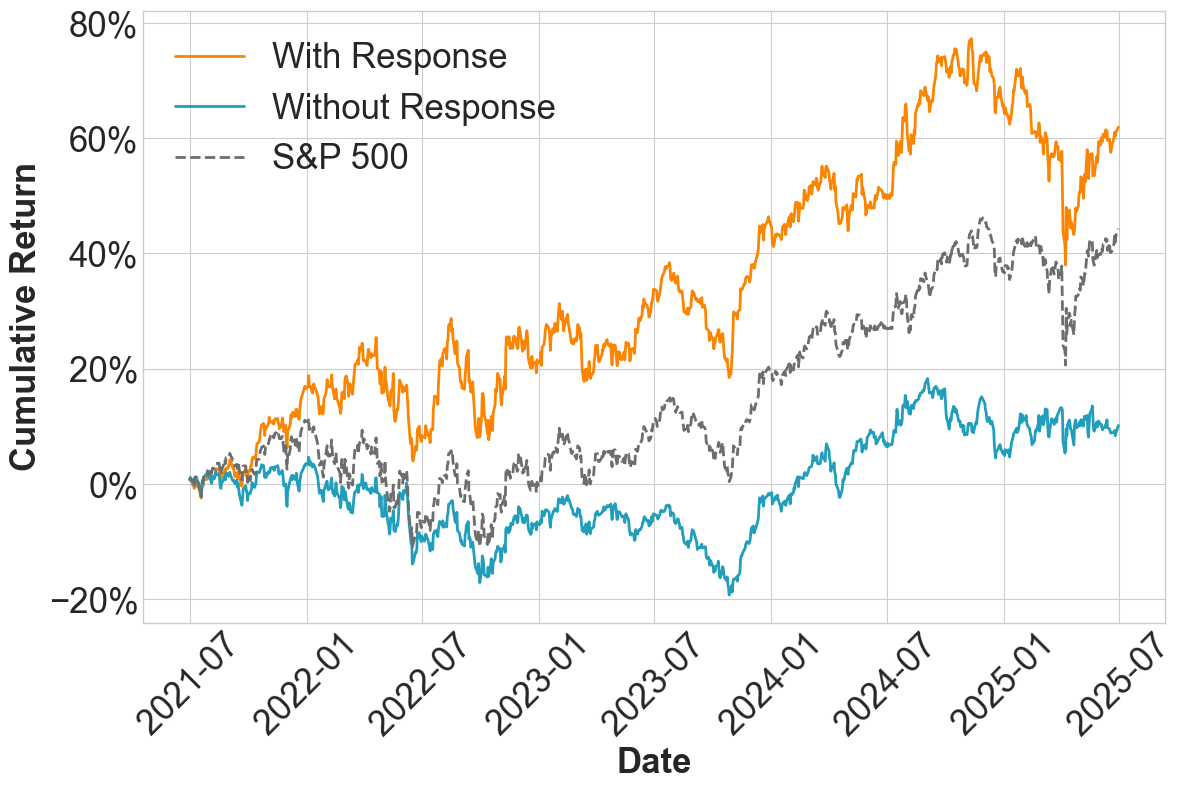

In [5]:
portfolios = construct_portfolio(*load_data(), split_num=20, bool_print=False, action=0.15, no_action=0.85)  # Adjust split_num as needed
analyze_and_visualize(portfolios, end_date='2028-07-05')

Year: 2020
Shape of df_year: (362, 5)
High Risk Tickers: ['CCI', 'BLDR', 'WBD', 'MRNA', 'CTVA', 'CMG', 'ADP', 'AKAM', 'PM', 'AMP']
Low Risk Tickers: ['EMR', 'AMAT', 'ANET', 'MPC', 'HAS', 'HRL', 'BRO', 'CB', 'BALL', 'GOOG']
Year: 2021
Shape of df_year: (335, 5)
High Risk Tickers: ['CCI', 'CSGP', 'UBER', 'SBAC', 'STE', 'BFB', 'CPB', 'GLW', 'FDS', 'HPE']
Low Risk Tickers: ['MRK', 'TXN', 'CPRT', 'FDX', 'YUM', 'AXP', 'BKNG', 'LYV', 'KKR', 'HD']
Year: 2022
Shape of df_year: (226, 5)
High Risk Tickers: ['SLB', 'EPAM', 'SNA', 'UDR', 'CHTR', 'CCI', 'CMG', 'LYB', 'WST', 'CHRW']
Low Risk Tickers: ['AXP', 'AFL', 'ORLY', 'GEHC', 'TTWO', 'AMZN', 'VTRS', 'LHX', 'ABNB', 'VMC']
Year: 2023
Shape of df_year: (126, 5)
High Risk Tickers: ['BKNG', 'F', 'DD', 'NOC', 'VTRS', 'TDG', 'DUK', 'COR', 'MCK', 'STLD']
Low Risk Tickers: ['HSIC', 'EOG', 'CB', 'APTV', 'HWM', 'BIIB', 'HAL', 'EW', 'HES', 'ERIE']
        Annualized Return Annualized Volatility Sharpe Ratio Max Drawdown
High                7.39%            

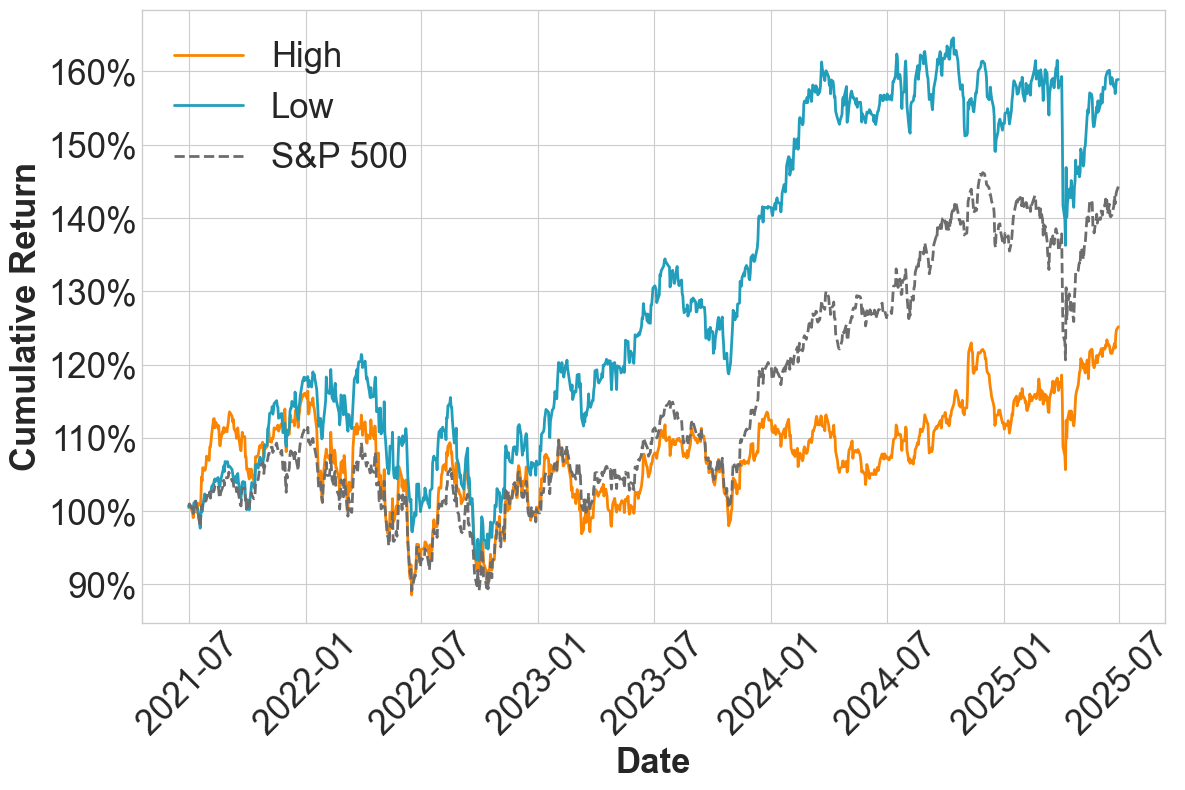

In [42]:
analyze_and_visualize(construct_portfolio_v2(*load_data(), split_num=10), end_date='2025-07-05')  # Adjust split_num as needed